In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [2]:
data = np.load(
    "../data/raw/IRISMIL_dataset_10000_bags.npz",
    allow_pickle=True
)


In [3]:
for key in data.files:
    try:
        print(key, data[key].shape)
    except:
        print(key, "→ object/meta data")


data (10000, 1100, 240)
data_scaled (10000, 1100, 240)
masks (10000, 1100)
groups (10000,)
obs_ids (10000,)
obs_classes (10000,)
raster_pos (10000,)
folds (10000,)


In [4]:
X = data["data_scaled"]     # use scaled data for models
mask = data["masks"]
y = data["obs_classes"]
groups = data["groups"]


KeyboardInterrupt: 

In [6]:
print("X shape:", X.shape)
print("Mask shape:", mask.shape)
print("y shape:", y.shape)
print("Groups shape:", groups.shape)


X shape: (10000, 1100, 240)
Mask shape: (10000, 1100)
y shape: (10000,)
Groups shape: (10000,)


In [7]:
unique, counts = np.unique(y, return_counts=True)
label_distribution = dict(zip(unique, counts))
label_distribution


{'AR': 5000, 'PF': 5000}

c:\Users\Haneesh.B\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


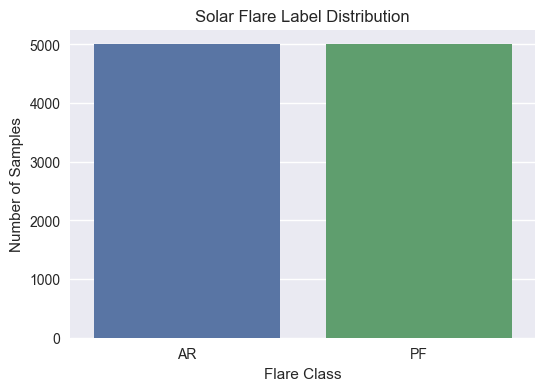

In [8]:
plt.figure(figsize=(6,4))      # Plot label distribution
sns.barplot(x=list(label_distribution.keys()),
            y=list(label_distribution.values()))
plt.title("Solar Flare Label Distribution")
plt.xlabel("Flare Class")
plt.ylabel("Number of Samples")
plt.show()


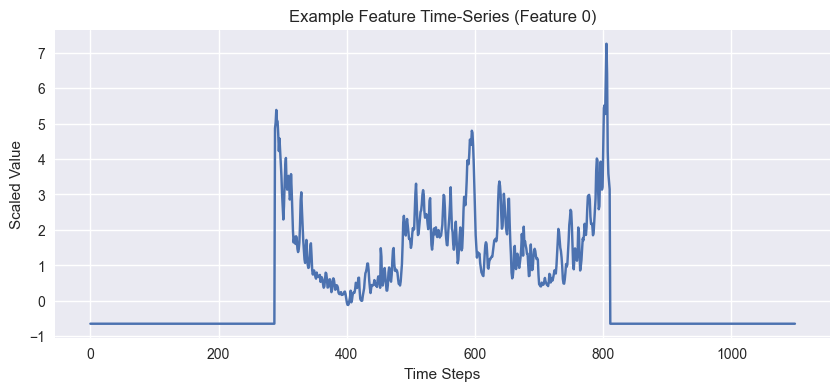

In [9]:
sample_id = 0    #Inspect One Time-Series Sample

plt.figure(figsize=(10,4))
plt.plot(X[sample_id, :, 0])
plt.title("Example Feature Time-Series (Feature 0)")
plt.xlabel("Time Steps")
plt.ylabel("Scaled Value")
plt.show()


In [10]:
valid_steps = mask[sample_id].sum()    #Check Valid Timesteps Using Mask
total_steps = mask.shape[1]

print(f"Valid timesteps: {valid_steps} / {total_steps}")


Valid timesteps: 523.0 / 1100


### Dataset Summary

- Dataset format: NPZ (NumPy compressed)
- Total samples (bags): 10,000
- Time steps per sample: 1,100
- Numerical features per timestep: 240
- Input data: Scaled numerical time-series
- Target variable: Solar flare class (`obs_classes`)
- Mask available: Yes (for valid timesteps)
- Class imbalance observed: Yes

This dataset is well-suited for numerical time-series based solar flare forecasting,
multiple instance learning, and simulated real-time prediction.
